In [2]:
!pip install pyspark --quiet
print('pyspark installed!!')

pyspark installed!!


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col, round as spark_round

import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

spark= SparkSession.builder \
    .appName('Day4_BigData_Sales') \
    .config('spark.sql.adaptive.enabled','true') \
    .getOrCreate()

print(f'Spark version : {spark.version}')
print(f'SparkSession : ACTIVE')
print(f'Application : {spark.conf.get("spark.app.name")}')


Spark version : 4.0.2
SparkSession : ACTIVE
Application : Day4_BigData_Sales


In [4]:
df_bronze = spark.read \
.option('header','true') \
.option('inferSchema','true') \
.csv('large_sales_data.csv')

print('===BRONZE LAYER - Raw Data===')
print(f'Rows :{df_bronze.count()}')

print(f'columns" {len(df_bronze.columns)}')
print(f'Names :{df_bronze.columns}')
print()
df_bronze.printSchema()

===BRONZE LAYER - Raw Data===
Rows :5000
columns" 13
Names :['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [5]:
print("first 5 rows:")
df_bronze.show(5,truncate= False)
print("\Basic statistics for numeric columns:")
df_bronze.select('quantity','unit_price','revenue').describe().show()

first 5 rows:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Ku

In [6]:
df_bronze.write \
    .mode('overwrite') \
    .parquet('sales_bronze.parquet')
print('bronze Parquet saved: sales_bronze.parquet')
import os
def get_dir_size(path):
  if os.path.isfile(path):
    return os.path.getsize(path) /1024
  total=0
  for dirpath,dirnames,filenames in os.walk(path):
    for f in filenames:
      total+=os.path.getsize(os.path.join(dirpath,f))
    return total /1024

csv_size = get_dir_size('large_sales_data.csv')
parquet_size = get_dir_size('sales_bronze.parquet')
reduction = (1-parquet_size/csv_size)*100

print(f'\nCsv size : {csv_size:.1f}KB')
print(f'Parquet size : {parquet_size:.1f}KB')
print(f'Reduction:{reduction:.1f}%smaller')

bronze Parquet saved: sales_bronze.parquet

Csv size : 529.3KB
Parquet size : 55.1KB
Reduction:89.6%smaller


In [7]:
df_silver = df_bronze \
   .dropDuplicates() \
   .dropna(subset=['order_id','product','revenue'])

df_silver = df_silver.withColumn(
    'order_date',
    to_date(col('order_date'),'yyyy-MM-dd')
)
df_silver = df_silver \
    .withColumn('year',year(col('order_date'))) \
    .withColumn('month',month(col('order_date')))

df_silver = df_silver.withColumn(
    'revenue_category',
    F.when(col('revenue')>4000,'High')\
     .when(col('revenue')>1000,'Medium')\
     .otherwise('Low')
)
print('===SILVER LAYER - Processed Data===')
print(f'Rows :{df_silver.count()}')
print('New columns added: year,month,revenue_category')
df_silver.select('product','revenue','year','month','revenue_category').show(5)

===SILVER LAYER - Processed Data===
Rows :5000
New columns added: year,month,revenue_category
+--------+-------+----+-----+----------------+
| product|revenue|year|month|revenue_category|
+--------+-------+----+-----+----------------+
|Keyboard|  13200|2023|    2|            High|
|  Webcam|  17500|2023|    1|            High|
| Speaker|  58500|2023|    4|            High|
|Keyboard|   9600|2023|   12|            High|
|  Laptop| 180000|2023|    8|            High|
+--------+-------+----+-----+----------------+
only showing top 5 rows


In [8]:
df_silver.write \
  .mode('overwrite') \
  .parquet('sales_silver.parquet')
print('silver Parquet saved: sales_silver.parquet')
print(f'silver size:{get_dir_size("sales_silver.parquet"):.1f}KB')

df_verify = spark.read.parquet('sales_silver.parquet')
print('\n===Verify Silver layer===')
print(f'Read-back rows: {df_verify.count()}(should match Silver count)')
df_verify.printSchema()

silver Parquet saved: sales_silver.parquet
silver size:59.5KB

===Verify Silver layer===
Read-back rows: 5000(should match Silver count)
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [9]:
top_products = df_silver \
     .groupBy('product') \
     .agg(
         F.sum('revenue').alias('total_revenue'),
         F.count('order_id').alias('num_orders'),
         F.avg('revenue').alias('avg_order_revenue')
     ) \
     .orderBy('total_revenue',ascending=False) \
     .limit(5)
print('===TOP 5 PRODUCTS===')
top_products.show(truncate = True)

===TOP 5 PRODUCTS===
+-------+-------------+----------+------------------+
|product|total_revenue|num_orders| avg_order_revenue|
+-------+-------------+----------+------------------+
| Laptop|    182700000|       502|363944.22310756973|
| Tablet|    135104000|       532| 253954.8872180451|
|Monitor|     82126000|       481|170740.12474012474|
|Printer|     44544000|       488| 91278.68852459016|
|Speaker|     16317000|       470| 34717.02127659575|
+-------+-------------+----------+------------------+



In [10]:
region_revenue = df_silver \
     .groupBy('region') \
     .agg(
         F.sum('revenue').alias('total_revenue'),
         F.count('order_id').alias('num_orders'),
         F.countDistinct('customer_name').alias('unique_customers')
     ) \
     .orderBy('total_revenue',ascending=False) \
     .limit(5)
print('===TOP 5 REGIONS===')
region_revenue.show(truncate = True)


===TOP 5 REGIONS===
+------+-------------+----------+----------------+
|region|total_revenue|num_orders|unique_customers|
+------+-------------+----------+----------------+
|  West|    198275600|      2021|              15|
| South|    147145900|      1483|              15|
| North|     99878400|       995|              15|
|  East|     50547700|       501|              15|
+------+-------------+----------+----------------+



In [11]:
monthly_revenue_trend = df_silver \
    .groupBy('month') \
    .agg(
        F.sum('revenue').alias('monthly_revenue'),
        F.count('order_id').alias('monthly_orders')
    ) \
    .orderBy('month')

print("=== Monthly Revenue Trend ===")
monthly_revenue_trend.show(truncate=False)

=== Monthly Revenue Trend ===
+-----+---------------+--------------+
|month|monthly_revenue|monthly_orders|
+-----+---------------+--------------+
|1    |41068200       |423           |
|2    |34485400       |375           |
|3    |40031200       |451           |
|4    |38857100       |390           |
|5    |39984500       |423           |
|6    |40707400       |390           |
|7    |42640700       |405           |
|8    |43718500       |418           |
|9    |37640200       |398           |
|10   |47839000       |479           |
|11   |44577100       |419           |
|12   |44298300       |429           |
+-----+---------------+--------------+



In [12]:
monthly_revenue = df_silver \
    .withColumn('month_name', F.date_format(F.col('order_date'), 'MMMM')) \
    .groupBy('month', 'month_name') \
    .agg(
        F.sum('revenue').alias('revenue_monthly'),
        F.count('order_id').alias('orders_monthly')
    ) \
    .orderBy('month') \
    .select('month_name', 'revenue_monthly', 'orders_monthly')

print("=== Monthly Revenue and orders ===")
monthly_revenue.show(truncate=False)

=== Monthly Revenue and orders ===
+----------+---------------+--------------+
|month_name|revenue_monthly|orders_monthly|
+----------+---------------+--------------+
|January   |41068200       |423           |
|February  |34485400       |375           |
|March     |40031200       |451           |
|April     |38857100       |390           |
|May       |39984500       |423           |
|June      |40707400       |390           |
|July      |42640700       |405           |
|August    |43718500       |418           |
|September |37640200       |398           |
|October   |47839000       |479           |
|November  |44577100       |419           |
|December  |44298300       |429           |
+----------+---------------+--------------+



In [13]:
gold_region = region_revenue
gold_region.write.mode('overwrite').parquet('gold_region_revenue.parquet')
print("Gold 1 saved: gold_region_revenue.parquet")

gold_products = df_silver \
    .groupBy('product','category') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('num_orders'),
        spark_round(F.avg('revenue'),1).alias('avg_quantity_per_order'),
        F.max('revenue').alias('largest_order')
    ) \
    .orderBy('total_revenue',ascending=False)
gold_products.write.mode('overwrite').parquet('gold_products_revenue.parquet')
print("Gold 2 saved: gold_products_revenue.parquet")

Gold 1 saved: gold_region_revenue.parquet
Gold 2 saved: gold_products_revenue.parquet


In [14]:
region_pd = spark.read.parquet('gold_region_revenue.parquet').toPandas()
products_pd = spark.read.parquet('gold_products_revenue.parquet').toPandas()
monthly_pd = monthly_revenue_trend.toPandas()
print('Gold tables converted to apandas:')
print(f'region_pd: {region_pd.shape}')
print(f'products_pd: {products_pd.shape}')
print(f'monthly_pd: {monthly_pd.shape}')

region_pd = region_pd.sort_values('total_revenue',ascending=False)
products_pd = products_pd.sort_values('total_revenue',ascending=False)
monthly_pd = monthly_pd.sort_values('month')

Gold tables converted to apandas:
region_pd: (4, 4)
products_pd: (10, 6)
monthly_pd: (12, 3)


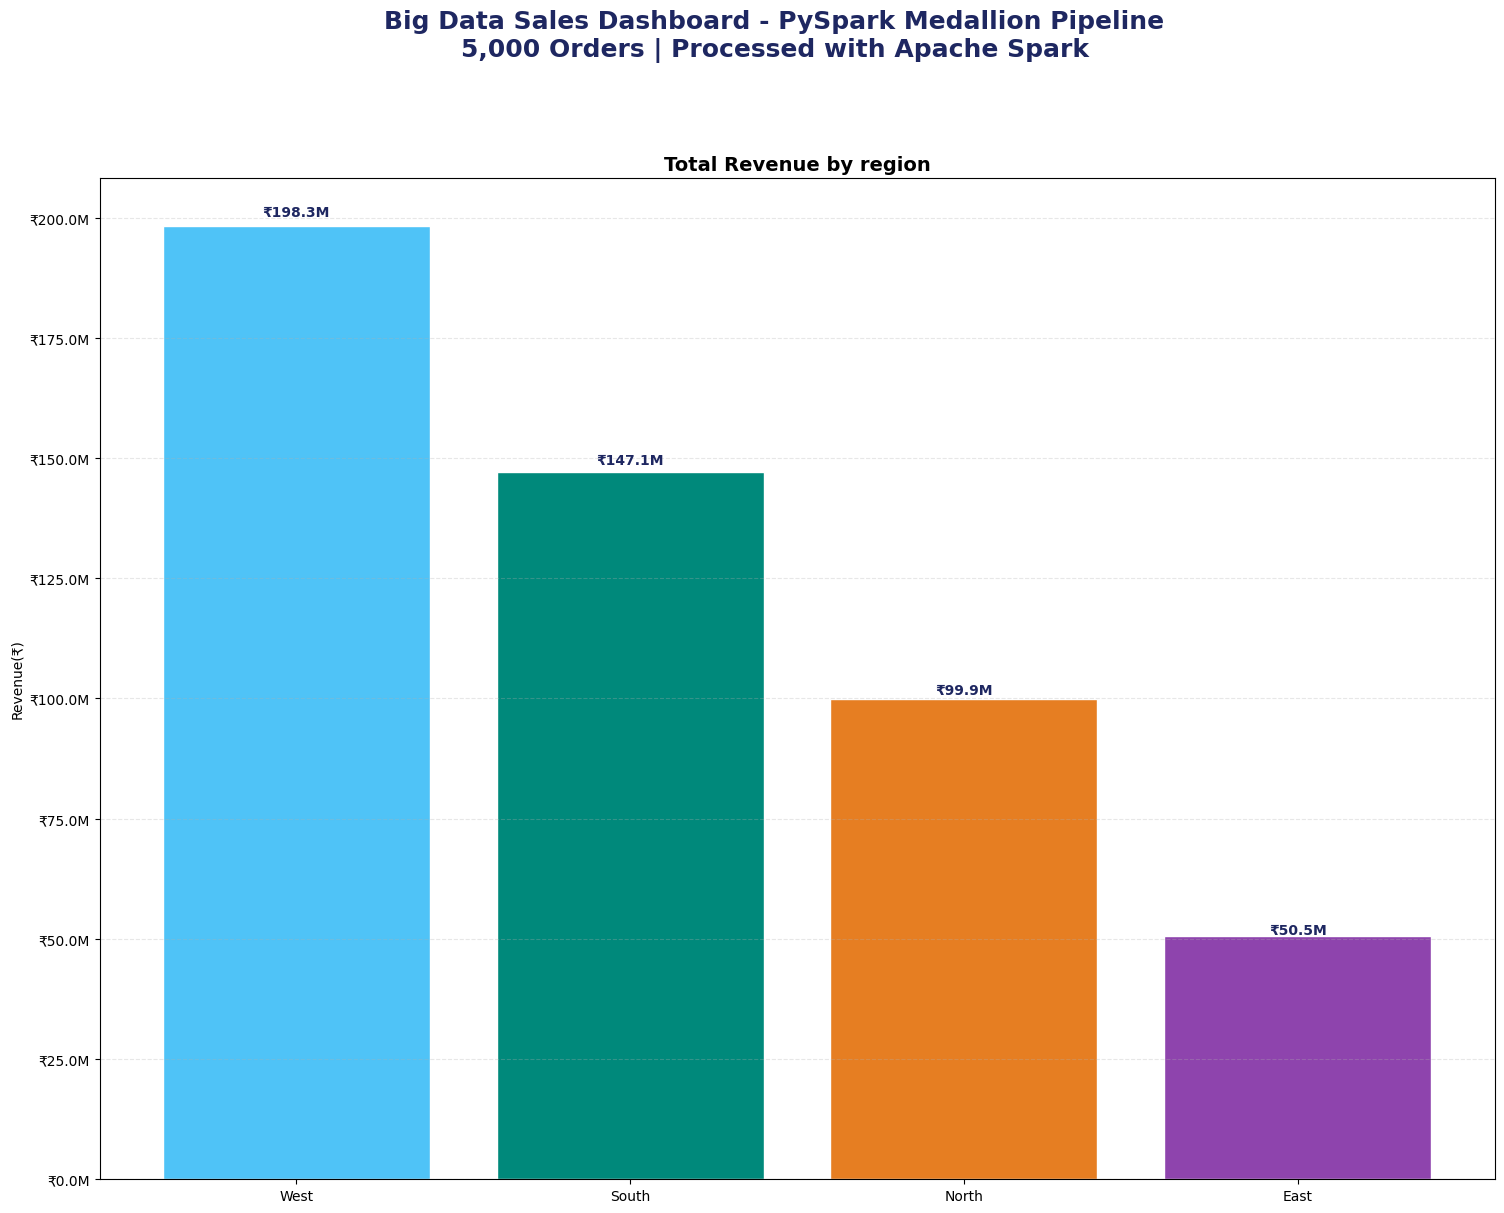

In [15]:
fig , axes = plt.subplots(1,1,figsize=(18,13))
fig.suptitle(
    'Big Data Sales Dashboard - PySpark Medallion Pipeline\n'
    '5,000 Orders | Processed with Apache Spark',
    fontsize=18, fontweight='bold',color = '#1E2761',y=1.01
)
colors4 = ['#4FC3F7','#00897B','#E67E22','#8E44AD','#E74C3C']
ax1 = axes
bars1 = ax1.bar(region_pd['region'],region_pd['total_revenue'],color=colors4[:len(region_pd)],edgecolor='white')

for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.01,f'₹{bar.get_height()/1e6:.1f}M',ha='center'
  ,fontsize =10,fontweight='bold',color='#1E2761')
  ax1.set_title('Total Revenue by region',fontsize=14,fontweight='bold')
ax1.set_ylabel('Revenue(₹)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax1.grid(axis='y', alpha=0.3, linestyle='--')

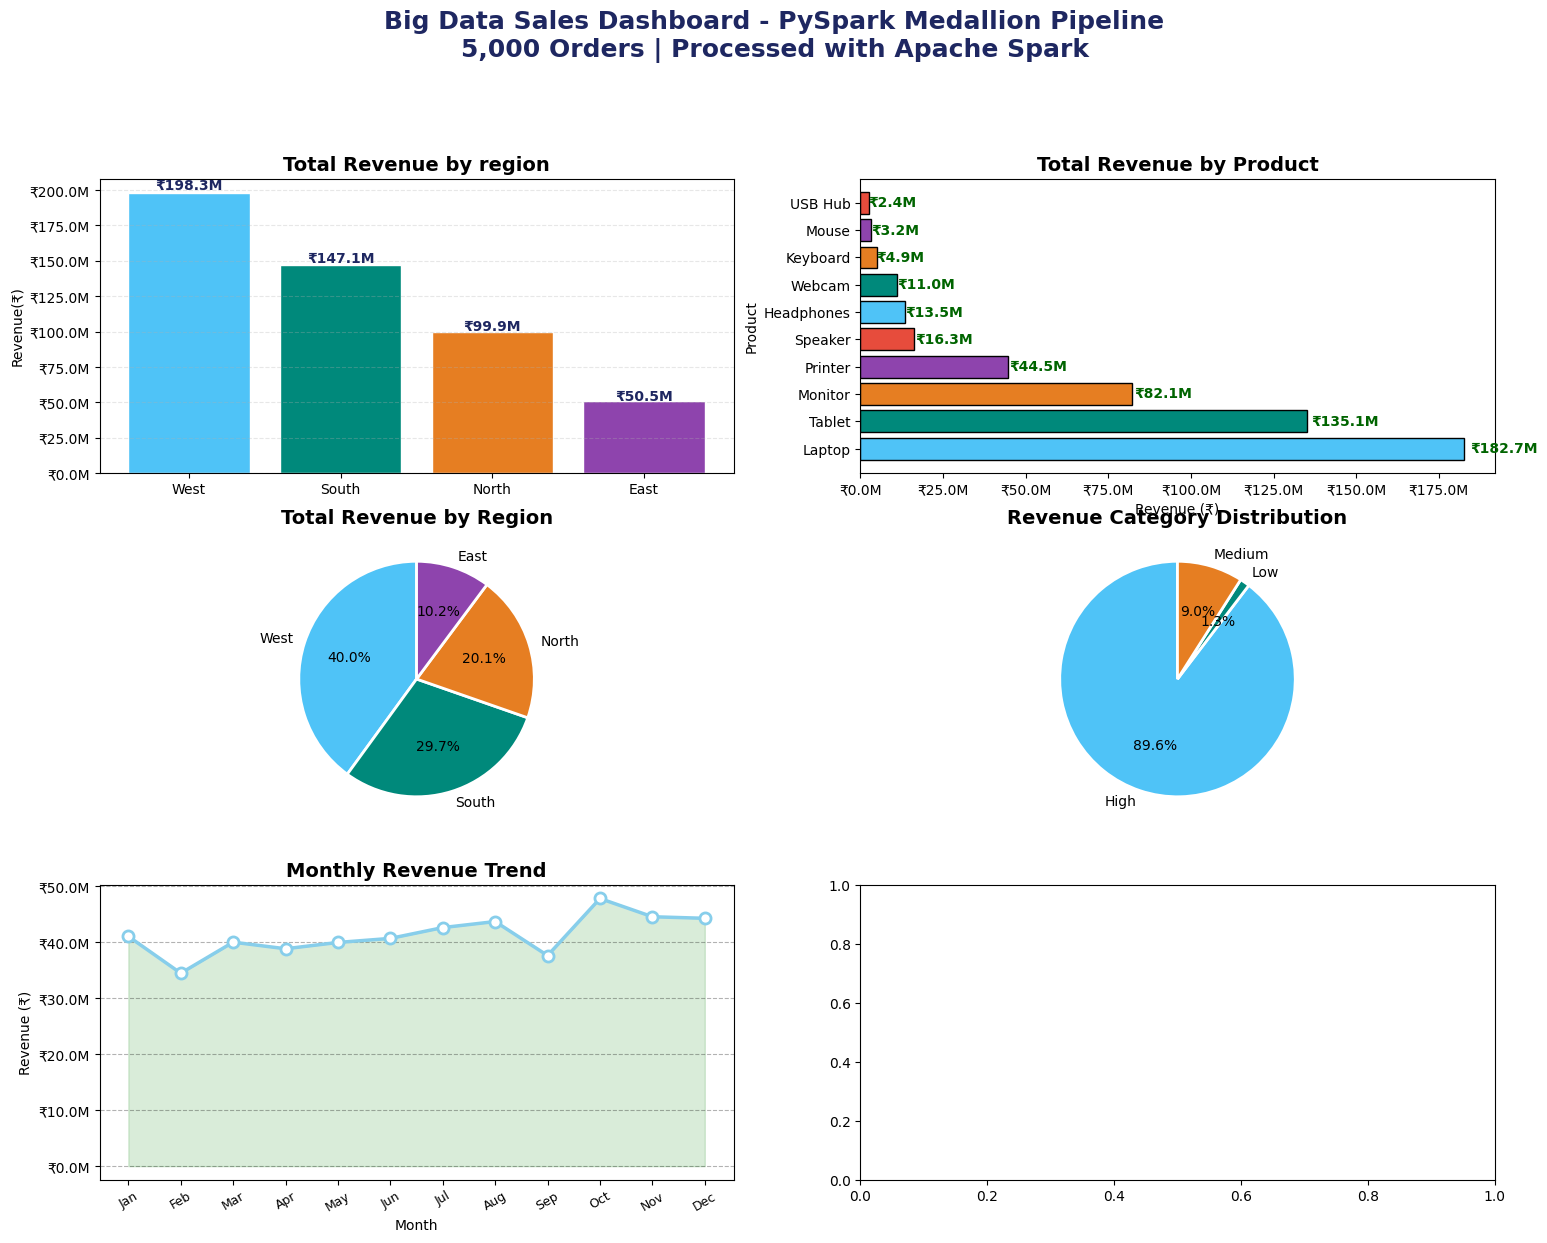

In [30]:
fig , axes = plt.subplots(3,2,figsize=(18,13))
fig.suptitle(
    'Big Data Sales Dashboard - PySpark Medallion Pipeline\n'
    '5,000 Orders | Processed with Apache Spark',
    fontsize=18, fontweight='bold',color = '#1E2761',y=1.01
)
colors4 = ['#4FC3F7','#00897B','#E67E22','#8E44AD','#E74C3C']
ax1 = axes[0][0]
bars1 = ax1.bar(region_pd['region'],region_pd['total_revenue'],color=colors4[:len(region_pd)],edgecolor='white')

for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.01,f'₹{bar.get_height()/1e6:.1f}M',ha='center'
  ,fontsize =10,fontweight='bold',color='#1E2761')
  ax1.set_title('Total Revenue by region',fontsize=14,fontweight='bold')
ax1.set_ylabel('Revenue(₹)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax2 = axes[0, 1]
bars2 = ax2.barh(products_pd['product'], products_pd['total_revenue'], color=colors4[:len(products_pd)],edgecolor='black')

for bar in bars2:
  ax2.text(bar.get_x() + bar.get_width()*1.01, bar.get_y() + bar.get_height()/2,
           f"₹{bar.get_width()/1e6 :.1f}M",
           va='center', fontsize=10,fontweight='bold',color='Darkgreen')

ax2.set_title("Total Revenue by Product",fontsize=14,fontweight='bold')
ax2.set_xlabel('Revenue (₹)')
ax2.set_ylabel('Product')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"₹{x/1e6:.1f}M"))

ax3 = axes[1, 0]
ax3.pie(
    region_pd['total_revenue'],
    labels=region_pd['region'],
    colors=colors4[:len(region_pd)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

ax3.set_title("Total Revenue by Region", fontsize=14, fontweight='bold')

ax4=axes[1, 1]
rev_cat = df_silver.groupBy('revenue_category').count().orderBy('revenue_category').toPandas()
ax4.pie(rev_cat['count'],
        labels=rev_cat['revenue_category'],
        colors=['#4FC3F7','#00897B','#E67E22','#8E44AD','#E74C3C'],
        autopct='%1.1f%%',startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax4.set_title('Revenue Category Distribution',fontsize=14,fontweight='bold')
ax5 = axes[2,0]
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_labels = [month_names[m-1] for m in monthly_pd['month']]
ax5.plot(monthly_labels,monthly_pd['monthly_revenue'],
         marker='o',linewidth=2.5,color='SkyBlue',
         markersize=8,markerfacecolor='white',markeredgewidth=2)
ax5.fill_between(range(len(monthly_labels)),
                 monthly_pd['monthly_revenue'],
                 alpha=0.15,color='green')
ax5.set_title('Monthly Revenue Trend',fontsize=14,fontweight='bold')
ax5.set_xlabel('Month')
ax5.set_ylabel('Revenue (₹)')
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"₹{x/1e6:.1f}M"))
ax5.grid(axis='y',alpha=0.3,linestyle='--',color='black')
ax5.tick_params(axis='x',rotation=30,labelsize=9)